# ROSbot XL - Simulation, Teleoperation, and SLAM

**Platform:** RosLab | ROS 2 Jazzy | Ubuntu 24.04 | Gazebo Harmonic  
**Robot:** Husarion ROSbot XL  
**Difficulty:** Beginner

---
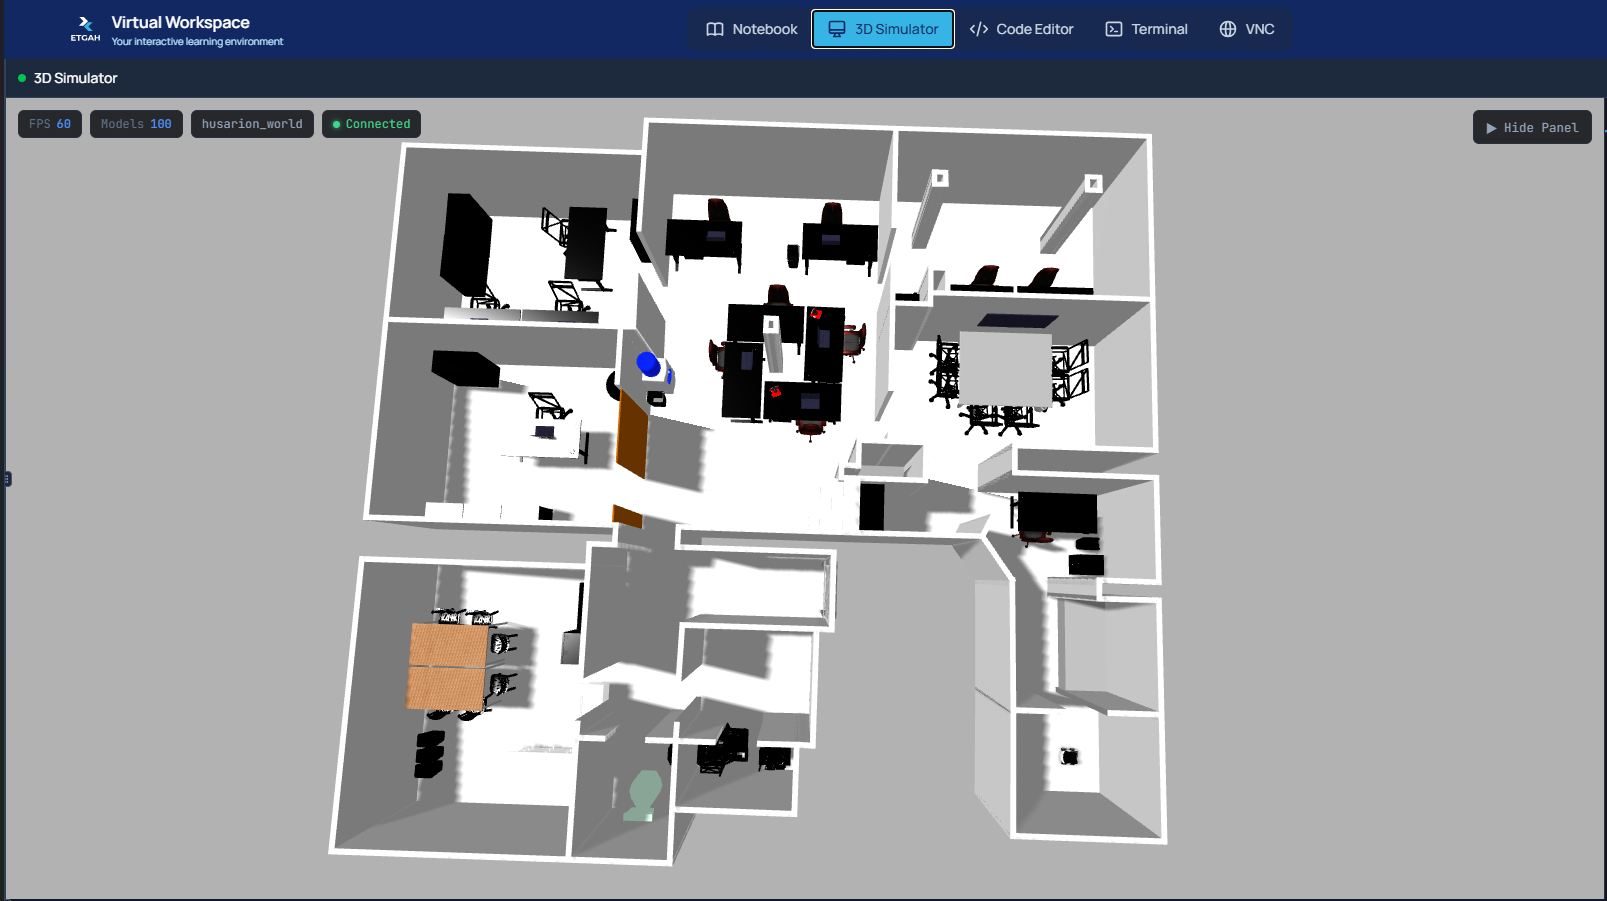

---

## What You Will Learn

This tutorial covers three core robotics skills using the ROSbot XL in simulation:

1. **Environment setup** - activating your workspace and understanding the RosLab interface
2. **Teleoperation** - driving the robot manually using the keyboard
3. **SLAM (Simultaneous Localization and Mapping)** - building a map of the environment while driving

## Prerequisites

- Basic familiarity with the RosLab interface (terminal, 3D Simulator panel, VNC panel)
- No prior ROS 2 experience required

---

## Tutorial Overview

| Section | Description |
|---------|-------------|
| 1. Workspace Setup | Activate the workspace in each terminal |
| 2. Launching the Simulation | Use the Worlds panel to launch the world + spawn the robot |
| 3. Teleoperation | Drive the robot using keyboard commands |
| 4. SLAM | Launch slam_toolbox and visualize map building in RViz |
| 5. Saving the Map | Save your completed map to disk |

---

# Meet the ROSbot XL

The **Husarion ROSbot XL** is a four-wheel mecanum-drive mobile robot - the mecanum wheels let it drive sideways and rotate in place, not just forward/backward like a differential-drive robot. For this course it's equipped with:

- A 2D LiDAR for obstacle detection and mapping (`/scan`)
- An IMU for orientation and angular velocity (`/imu/data`)
- Wheel encoders for odometry (`/odometry/wheels`)

This is exactly the sensor suite you'll use for SLAM in this tutorial, and later for autonomous navigation with Nav2.

![ROSbot XL in the ETGAH simulator](references/rosbot_xl_intro.png)
*(placeholder - screenshot of the ROSbot XL running in the ETGAH Gazebo simulator, `husarion_office` world)*


---

# Section 0 - Getting the Repository

Before setting up the workspace, clone the course repository. It contains the ROSbot XL packages, worlds, launch files, and all required dependencies vendored directly inside it. No additional import steps are needed.

Open a terminal and run the following commands one at a time.

In [ ]:
git clone https://github.com/ETGAH/Husarion_RosbotXL.git rosbot_xl


In [ ]:
ls ~/workspaces/rosbot_xl  

Expected output - the repository contents:

```
config/                          rosbot_localization/
husarion_components_description/ rosbot_utils/
husarion_gz_worlds/               rosbot/
husarion_mecanum_drive_controller/ rosbot_controller/
rosbot_description/               rosbot_gazebo/
```

The repository includes:

| Item | Description |
|------|-------------|
| 9 package folders (`rosbot_gazebo`, `rosbot_description`, `husarion_gz_worlds`, ...) | All required ROS 2 packages for the ROSbot XL simulation, sitting directly at the repo root - no `src/` wrapper needed, `colcon` finds packages recursively |
| `config/` | SLAM configuration file |

> 

---


---

### Install Dependencies

The workspace vendors all ROSbot XL packages directly at the repo root, but a handful of their dependencies still come from apt (ROS 2 Jazzy packages, Python libraries, etc.). Resolve those with `rosdep` before building - this is what prevents "package X not found" errors later in the tutorial.


In [ ]:
cd ~/workspaces/rosbot_xl && rosdep install --from-paths . --ignore-src -r -y


Expected output ends with a summary of installed/skipped packages and no `ERROR` lines. It's safe to re-run this command any time - packages already satisfied are skipped.



### Build the Workspace

Build the workspace via colcon build:

In [ ]:
cd ~/workspaces/rosbot_xl && colcon build --symlink-install --cmake-args -DCMAKE_BUILD_TYPE=Release

The build typically takes 5 to 10 minutes. You will see packages being compiled one by one. Wait for the summary line before continuing:

```
Summary: 9 packages finished [...]
```

> 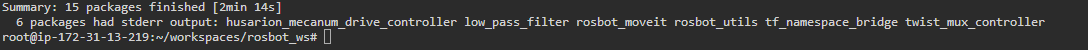

> **Tip:** To avoid sourcing the workspace manually in every new terminal, add it to your `.bashrc`:

```
echo "source ~/workspaces/rosbot_xl/install/setup.bash" >> ~/.bashrc
```

After running this once, new terminals will automatically have the workspace active.

---

### Expected Outcome - Section 0

By the end of this section you should have:

- The repository cloned at `~/workspaces/rosbot_xl/`
- `rosdep install` completed with no `ERROR` lines
- The workspace built with the summary showing `9 packages finished` and no errors
- A `src/` folder containing all ROSbot XL packages


---

# Section 1 - Workspace Setup

RosLab comes with all required packages pre-installed. Before running any ROS 2 commands, you need to activate the workspace in your terminal so the system knows where to find the ROSbot packages.

Run the following command in your terminal to source the workspace:

In [ ]:
source ~/workspaces/rosbot_xl/install/setup.bash

In [ ]:
ros2 pkg list | grep rosbot

You should see packages including `rosbot_xl`, `rosbot_description`, `rosbot_gazebo`, and others. If nothing appears, make sure you ran the `source` command above first.

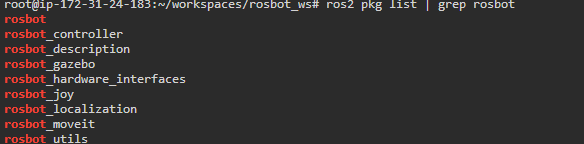

---

# Section 2 - Launching the Simulation

### Step 2.1 - Launch from the Worlds Panel

Simulations on this platform are launched from the ETGAH **Worlds panel**, not the terminal. The panel lists any `*.launch.py` file in your active workspace that starts a Gazebo world, and `rosbot_gazebo`'s `sim.launch.py` is the one that brings up everything for this tutorial in a single click: the `husarion_office` world, the ROSbot XL (`autonomy` configuration, full sensor suite including LiDAR), the ROS<->Gazebo bridge, the drive controllers, the EKF, and RViz.

1. Activate the `rosbot_xl` workspace (top bar / workspace selector).
2. Open the **Worlds** panel.
3. Select **`rosbot_gazebo` / `sim.launch.py`** from the list.
4. Press **Launch**.

![worlds panel launch](references/worlds_panel_launch.gif)
*(placeholder - record: activate workspace -> open Worlds panel -> select `rosbot_gazebo` / `sim.launch.py` -> press Launch -> robot spawns in `husarion_office`)*

> **Under the hood**, the panel runs `ros2 launch rosbot_gazebo sim.launch.py`, which is a thin wrapper around `simulation.yaml` with course defaults baked in (`robot_model:=rosbot_xl configuration:=autonomy gz_world:=husarion_office x:=0.0 y:=0.0 z:=0.1 rviz:=True`). You don't need to run this yourself - it's shown here only so you understand what's starting up.


After pressing Launch, wait for the output to settle - Gazebo and RViz both take a few minutes to fully start, and RViz opens automatically in the VNC panel once the robot has spawned.

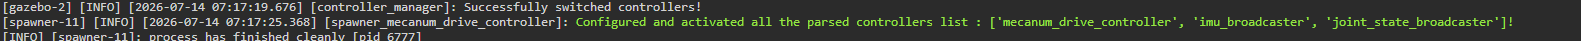

Office world launched succesfully with robot



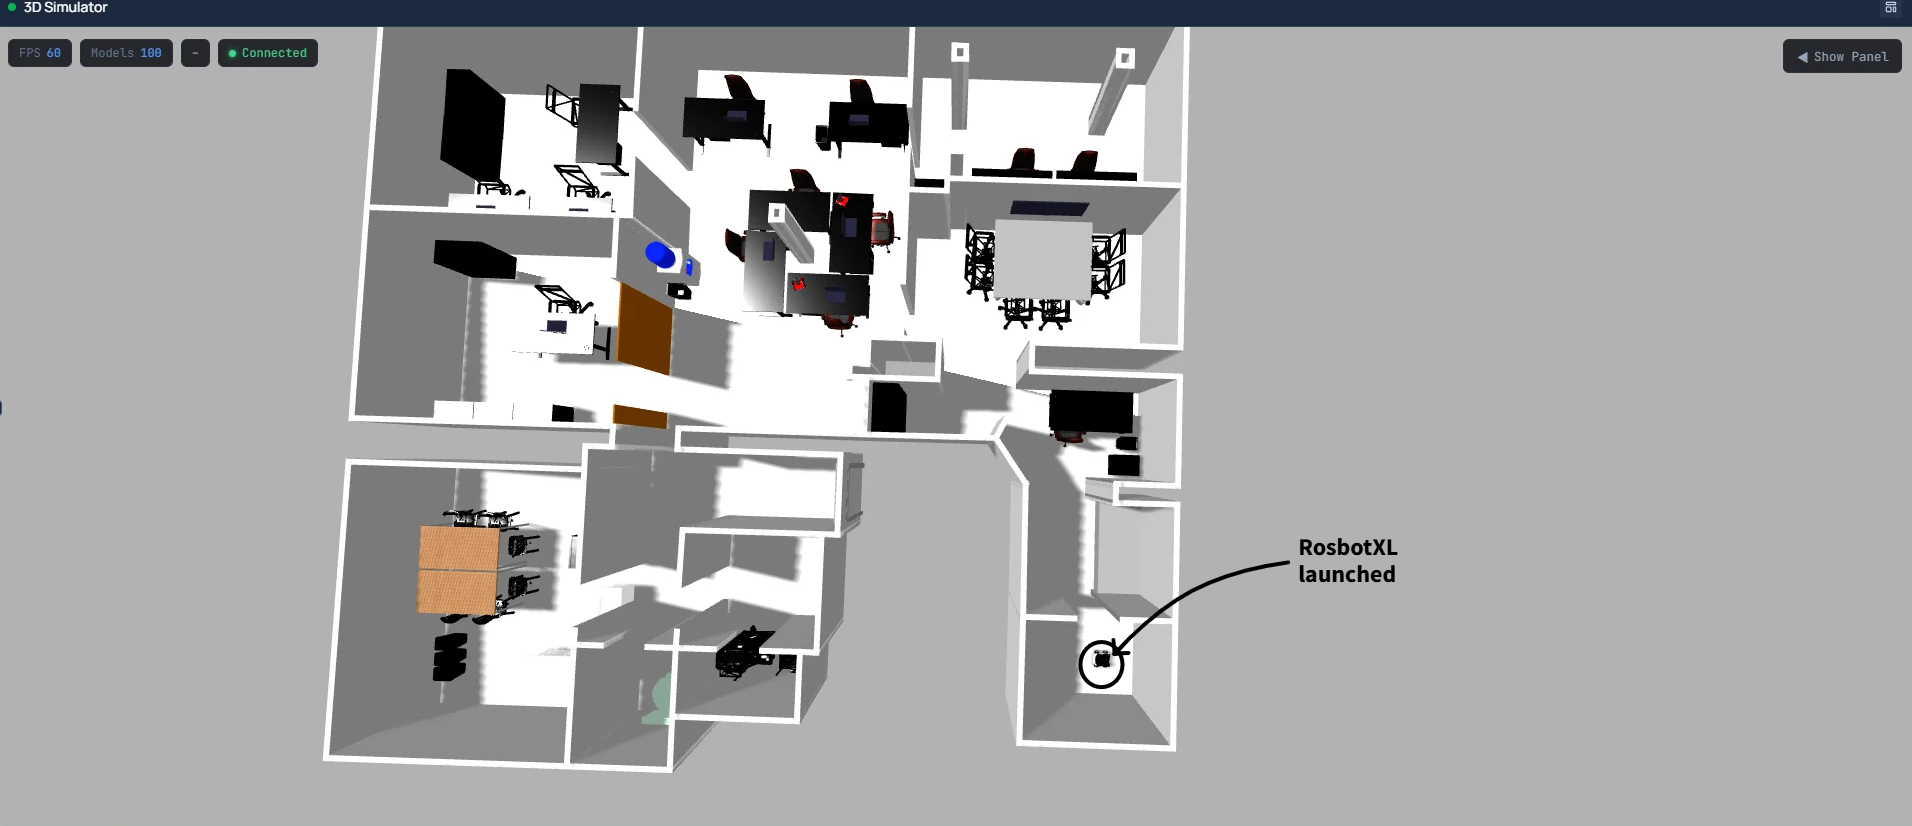


RVIZ launched in VNC with sensors, robot, and topics

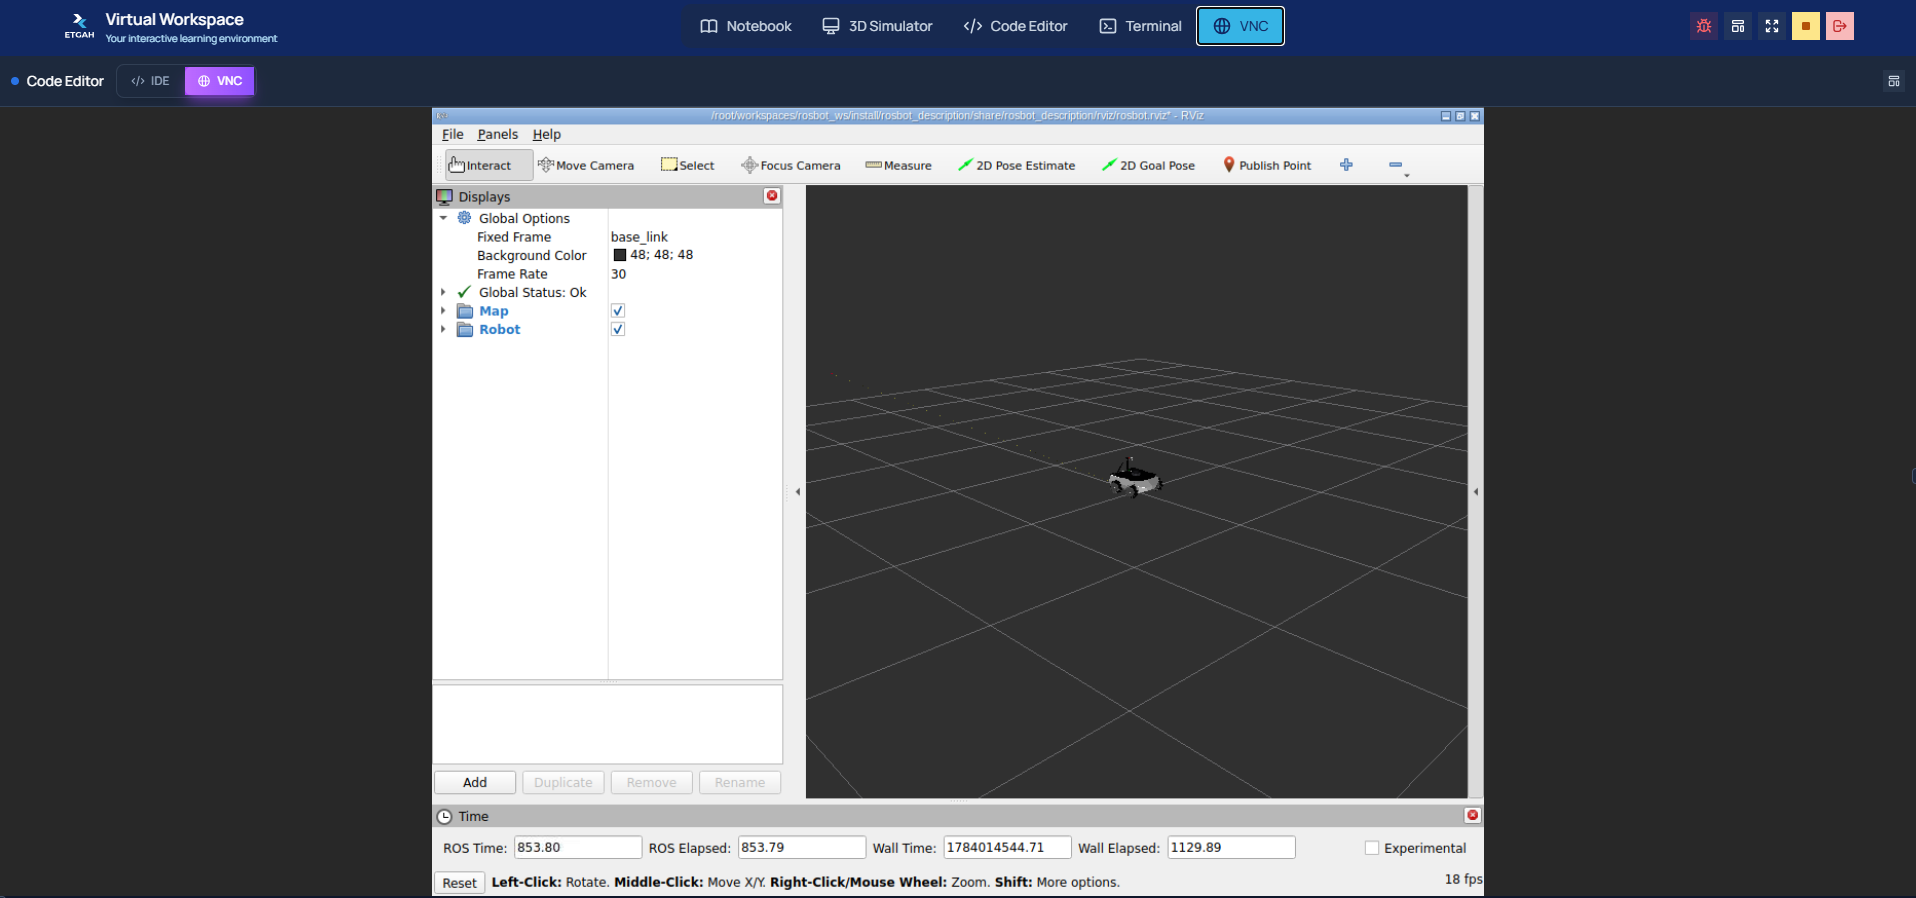
---

### Verify the Simulation is Running

Open a **new terminal** and check that the robot topics are active:

In [ ]:
source ~/workspaces/rosbot_xl/install/setup.bash

In [ ]:
ros2 topic list

You should see topics including:

- `/cmd_vel` - velocity commands sent to the robot
- `/scan` - laser scanner data from the LiDAR
- `/odom` - odometry (the robot tracking its own position)
- `/clock` - simulation clock

If `/scan` and `/cmd_vel` are both present, the robot has spawned correctly.

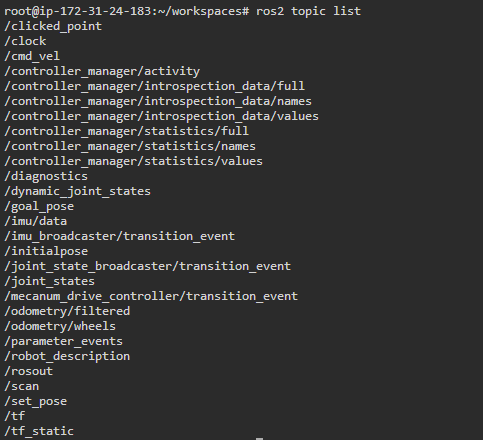

> **Note:** You may see `RTPS_TRANSPORT_SHM` warnings in the launch terminal. These are harmless FastDDS shared memory warnings and do not affect the simulation.

---

### Understanding the Key Topics

| Topic | Type | Description |
|-------|------|-------------|
| `/cmd_vel` | `geometry_msgs/TwistStamped` | Velocity commands - linear and angular speed |
| `/scan` | `sensor_msgs/LaserScan` | 2D LiDAR readings in frame `laser` |
| `/odom` | `nav_msgs/Odometry` | Robot estimated position from wheel encoders |
| `/tf` | `tf2_msgs/TFMessage` | Coordinate frame transforms |

---

### Expected Outcome - Section 2

The simulation is running correctly if:

- The launch command completes without errors
- RViz opens in the VNC panel showing the ROSbot XL in the office environment
- `ros2 topic list` returns topics including `/cmd_vel`, `/scan`, `/odom`, and `/clock`
- The `/scan` topic is publishing at approximately 10 Hz

If nothing appears in the Worlds panel or the launch fails, check the panel's log/status area first, and confirm `rosbot_gazebo` appears in `ros2 pkg list` in a sourced terminal - see Troubleshooting at the end of this notebook.

---

# Section 3 - Teleoperation

Teleoperation (teleop) means controlling the robot manually by sending velocity commands. The `teleop_twist_keyboard` package reads your keyboard input and publishes movement commands to `/cmd_vel`.

### How cmd_vel Works

The `/cmd_vel` topic carries a `TwistStamped` message with two components:

- **Linear velocity** - forward/backward speed in metres per second
- **Angular velocity** - rotation speed in radians per second

> **Note for ROS 2 Jazzy users:** In ROS 2 Jazzy, the `/cmd_vel` topic uses `TwistStamped` instead of `Twist` (which was used in older versions). The teleop node must be launched with the `-p stamped:=true` flag. Without it, the robot will not move even if keys are pressed.

---

### Launch Teleop

Open a **new terminal**, source the workspace, then run:

In [ ]:
source ~/workspaces/rosbot_xl/install/setup.bash

In [ ]:
ros2 run teleop_twist_keyboard teleop_twist_keyboard --ros-args -p stamped:=true

The terminal will display the keyboard controls:

```
Moving around:
   u    i    o
   j    k    l
   m    ,    .

i - move forward
, - move backward
j - turn left
l - turn right
k - stop
```

> **Important:** The terminal running teleop must have keyboard focus (click on it first). If you click on another panel, key presses will not reach the robot.



![teleop](references/teleop.gif)
*(placeholder - record: drive forward/turn with teleop while the Gazebo/RViz view is visible, save as `references/teleop.gif`)*




### Adjusting Speed

While teleop is running, press these keys to change speed:

| Key | Action |
|-----|--------|
| `q` | Increase both linear and angular speed |
| `z` | Decrease both linear and angular speed |
| `w` | Increase linear speed only |
| `x` | Decrease linear speed only |
| `e` | Increase angular speed only |
| `c` | Decrease angular speed only |

The current speed values are printed in the terminal as you adjust them.

---

### Confirm the Robot is Receiving Commands

Open a second terminal and run the following to confirm velocity commands are being published when you press keys:

In [ ]:
ros2 topic echo /cmd_vel

While pressing a direction key in the teleop terminal, you should see messages appearing here with non-zero `linear.x` or `angular.z` values. Press `Ctrl+C` to stop echoing.

---

### Check the LiDAR is Active

The ROSbot XL has a 2D LiDAR sensor. Confirm it is publishing data:

In [ ]:
ros2 topic hz /scan

Expected output: approximately `10 Hz`. This confirms the LiDAR is running and will provide the sensor data needed for SLAM in the next section. Press `Ctrl+C` to stop.

---

### Expected Outcome - Section 3

Teleoperation is working correctly if:

- Pressing `i` in the teleop terminal causes the robot to move forward in the simulation
- `ros2 topic echo /cmd_vel` shows messages with non-zero values while keys are held
- `/scan` is publishing at approximately 10 Hz, confirming the LiDAR is active


---

# Section 4 - SLAM (Simultaneous Localization and Mapping)

SLAM allows a robot to build a map of an unknown environment while simultaneously tracking its own position within that map. The robot does not need a map in advance - it builds one as it explores.

### How It Works

The ROSbot XL uses two inputs to perform SLAM:

- **LiDAR (`/scan`)** - measures distances to walls and obstacles in all directions
- **Odometry (`/odom`)** - tracks how far the robot has moved based on wheel rotations

The SLAM algorithm (`slam_toolbox`) combines these two data streams to:
1. Build an occupancy grid map (a grid where each cell is marked as free, occupied, or unknown)
2. Correct position drift by matching new LiDAR scans against the existing map

---

### Step 4.1 - Make Sure the Simulation is Still Running

SLAM requires the simulation to be active. If you stopped it, go back to the **Worlds panel** and press **Launch** again on **`rosbot_gazebo` / `sim.launch.py`** (see Section 2). Then source and confirm `/scan` is publishing before continuing.

---

### Step 4.2 - Launch slam_toolbox

Open a **new terminal** and run:

In [ ]:
source ~/workspaces/rosbot_xl/install/setup.bash

In [ ]:
ros2 launch slam_toolbox online_async_launch.py \
    use_sim_time:=true \
    slam_params_file:=/root/workspaces/rosbot_xl/config/slam_params.yaml

Two important flags:

- `use_sim_time:=true` - required so SLAM uses the simulation clock, not your computer's clock. Without it the map builds incorrectly.
- `slam_params_file` - points to the custom params file in the repo. This sets the correct scan topic (`/scan`), frames, and update rates for the ROSbot XL. Note: use the full path starting with `/root/` - ROS 2 launch does not expand `~`.

You will see output like:
```
[async_slam_toolbox_node-1]: Configuring
[async_slam_toolbox_node-1]: Activating
```

Leave this terminal running.

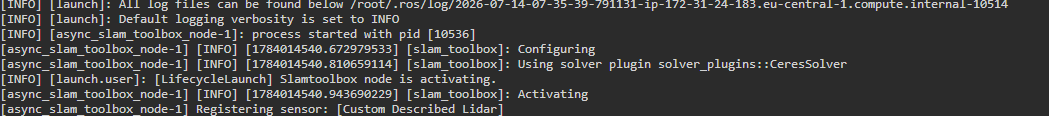

---

### Step 4.3 - Configure RViz to Show the Map

RViz is already open in the VNC panel from the simulation launch. You now need to configure it to display the map.

**1. Add map in RVIZ to view mapping **

In the left bottom, find the `add` button and press it.

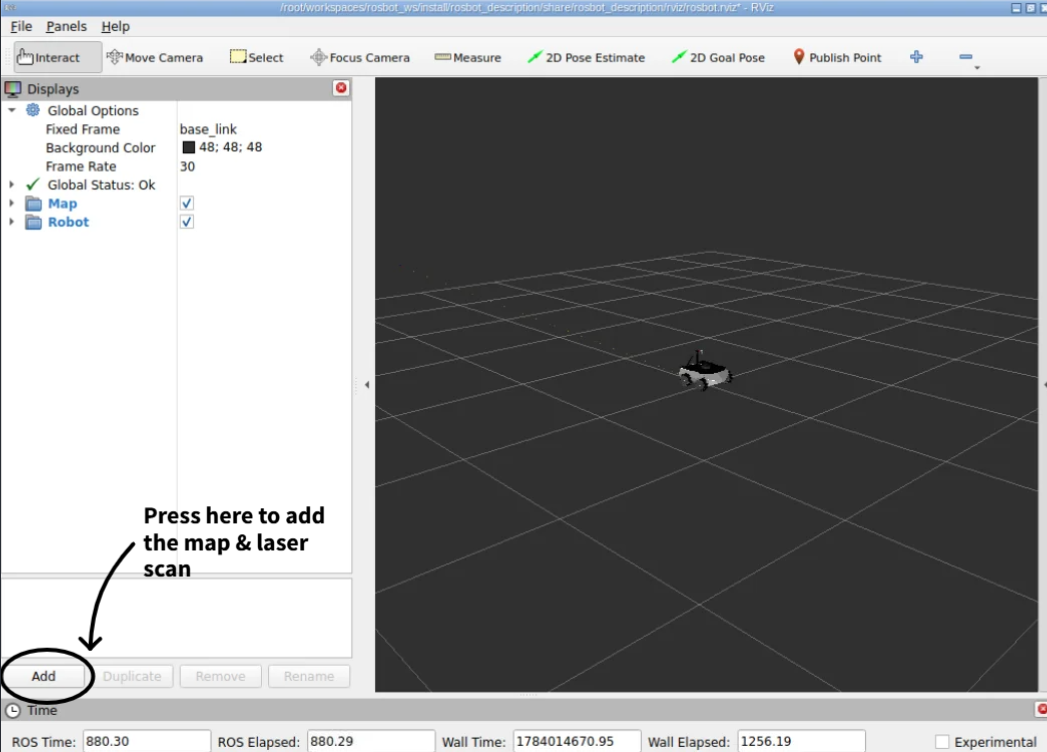

**2. Add the Map display**

- Select the **By Topic** tab
- Find `/map` and select **Map**
- Click **OK**

**3. Add the LaserScan display**

- Click **Add** again
- Select the **By Topic** tab
- Find `/scan` and select **LaserScan**
- Click **OK**


In [ ]:
ros2 topic echo /map --once | grep -E "width|height|resolution"

Expected output will look similar to:

```
  resolution: 0.05000000074505806
  width: 285
  height: 282
```

The `width` and `height` values will grow as you map more of the environment. A `resolution` of `0.05` means each grid cell represents 5 centimetres of real space.

---

### Understanding the TF Tree

SLAM relies on the Transform (TF) system to know where sensor readings come from relative to the robot. The key chain is:

```
map --> odom --> base_link --> laser
```

- `map` to `odom` - published by slam_toolbox, corrects for drift
- `odom` to `base_link` - published by the robot, based on wheel odometry
- `base_link` to `laser` - static transform, the LiDAR position on the robot

Check that this chain is intact:

In [ ]:
ros2 run tf2_tools view_frames

This creates a `frames.pdf` file in the current directory showing the full TF tree. Open it in the VNC panel to inspect the frame connections.

*(placeholder - open `frames.pdf` in the VNC panel and add a screenshot here showing the `map -> odom -> base_link -> laser` chain)*

---

### Expected Outcome - Section 4

SLAM is working correctly if:

- RViz shows a white area (mapped free space) with black edges (walls) growing as you drive
- Red dots from the laser scan align with the black wall boundaries
- The Map display in RViz shows "Map received" in its status
- `ros2 topic hz /map` returns a publish rate (approximately 1 Hz)



![mapping](references/mapping.gif)
*(placeholder - record: RViz Map + LaserScan displays filling in as the robot drives around `husarion_office`, save as `references/mapping.gif`)*




If the map is not appearing, confirm:

- Fixed Frame is set to `map` in RViz
- slam_toolbox was launched with the full path to `slam_params.yaml` (not `~/...`)
- The simulation is still running and `/scan` is publishing

---

# Section 5 - Saving the Map

Once you have mapped enough of the environment, save the map to disk. The saved map can be reused later for localization and autonomous navigation without needing to re-map the environment.

> **Important:** Run the save command while slam_toolbox is still running. Do not stop it before saving.

---

### Save the Map

Open a new terminal and run:

In [ ]:
source ~/workspaces/rosbot_xl/install/setup.bash

In [ ]:
ros2 run nav2_map_server map_saver_cli -f /root/workspaces/rosbot_xl/my_first_map

Expected output:

```
[map_saver]: Saving map from 'map' topic to '/root/workspaces/rosbot_xl/my_map' file
[map_io]: Received a 285 X 282 map @ 0.05 m/pix
[map_io]: Writing map occupancy data to /root/workspaces/rosbot_xl/my_first_map.pgm
[map_io]: Writing map metadata to /root/workspaces/rosbot_xl/my_map.yaml
[map_saver]: Map saved successfully
```

Two files are created:

| File | Description |
|------|-------------|
| `my_first_map.pgm` | The map image - white pixels are free space, black pixels are walls, grey is unknown |
| `my_first_map.yaml` | Map metadata - resolution, origin coordinates, occupancy thresholds |

---

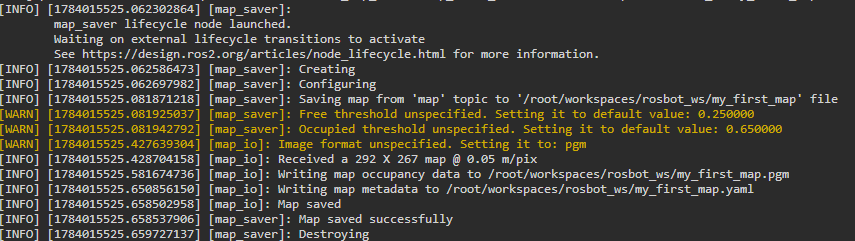

### Confirm the Files Exist

In [ ]:
ls /root/workspaces/rosbot_xl/my_first_map*

Expected output:
```
/root/workspaces/rosbot_xl/my_first_map.pgm
/root/workspaces/rosbot_xl/my_first_map.yaml
```

In [ ]:
cat /root/workspaces/rosbot_xl/my_first_map.yaml

Example output:

```yaml
image: my_map.pgm
mode: trinary
resolution: 0.05
origin: [-7.35, -6.85, 0.0]
negate: 0
occupied_thresh: 0.65
free_thresh: 0.25
```

- `resolution: 0.05` means each pixel represents 5 cm in the real world
- `origin` is the real-world coordinates of the bottom-left corner of the map image
- `occupied_thresh` - cells above this probability are marked as walls
- `free_thresh` - cells below this probability are marked as free


---

### Expected Outcome - Section 5

The map has been saved correctly if:

- Both `my_map.pgm` and `my_map.yaml` exist in `~/workspaces/rosbot_xl/`
- `my_map.yaml` contains a `resolution` of `0.05` and valid `origin` coordinates
- The `.pgm` image shows a recognizable floor plan with white corridors and black walls

These two files are all that is needed to load the map in future sessions for localization and autonomous navigation.

---

# Summary

In this tutorial you completed the following:

| Step | What You Did |
|------|--------------|
| Workspace Setup | Cloned the repo, resolved dependencies with `rosdep`, built with `colcon`, and sourced the workspace |
| Launching Simulation | Launched the ROSbot XL in the Husarion office world from the ETGAH Worlds panel (`rosbot_gazebo` / `sim.launch.py`) |
| Teleoperation | Drove the robot manually using `teleop_twist_keyboard` with the Jazzy TwistStamped fix |
| SLAM | Launched `slam_toolbox` and visualized the map building in RViz as you drove |
| Saving the Map | Saved the completed occupancy grid map as `.pgm` and `.yaml` files |

---

## Key Commands Reference

| Command | Purpose |
|---------|---------|
| `source ~/workspaces/rosbot_xl/install/setup.bash` | Activate workspace (run in every new terminal) |
| `ros2 topic list` | List all active ROS 2 topics |
| `ros2 topic hz /scan` | Check LiDAR publish rate |
| `ros2 run teleop_twist_keyboard teleop_twist_keyboard --ros-args -p stamped:=true` | Keyboard teleoperation |
| Worlds panel -> `rosbot_gazebo` / `sim.launch.py` | Launch the simulation (world + robot + RViz) - see Section 2 |
| `ros2 launch slam_toolbox online_async_launch.py use_sim_time:=true slam_params_file:=/root/workspaces/rosbot_xl/config/slam_params.yaml` | Start SLAM mapping |
| `rviz2` | Open RViz visualization |
| `ros2 run nav2_map_server map_saver_cli -f /root/workspaces/rosbot_xl/my_map` | Save the map to disk |

---

## What Comes Next

With a saved map, the next steps in this course are:

- **Localization** - using AMCL to locate the robot on the saved map without re-mapping
- **Autonomous Navigation** - using Nav2 to plan and follow paths to goal positions automatically

---

## Troubleshooting

**Robot does not move when keys are pressed**

- Check that the teleop terminal has keyboard focus (click on it)
- Make sure you included `--ros-args -p stamped:=true` in the teleop command
- Confirm `/cmd_vel` is receiving messages: `ros2 topic echo /cmd_vel`

**Map is not appearing in RViz**

- Make sure the Fixed Frame is set to `map` (not `base_link` or `odom`)
- Confirm slam_toolbox is running and `/map` is publishing: `ros2 topic hz /map`
- Make sure `use_sim_time:=true` was passed when launching slam_toolbox

**Topics are empty or not visible**

- Source the workspace again: `source ~/workspaces/rosbot_xl/install/setup.bash`
- Check the simulation is active in the Worlds panel's status area
- Press Launch again on `rosbot_gazebo` / `sim.launch.py` if it isn't running
- Run `ros2 doctor` for a general health check of your ROS 2 setup

**slam_toolbox prints TF errors**

- Wait 10-15 seconds after launching the simulation before starting slam_toolbox
- The TF tree takes a moment to fully initialize after the robot spawns

**World does not launch, or `rosbot_gazebo` / `sim.launch.py` is missing from the Worlds panel**

```
package 'rosbot_gazebo' not found
```

- The Worlds panel only lists `*.launch.py` files from your **built** workspace. Confirm the build finished with `Summary: 9 packages finished` and no errors (Section 0).
- Confirm the package exists: `ros2 pkg list | grep rosbot_gazebo` in a sourced terminal.
- If it's missing, rebuild: `cd ~/workspaces/rosbot_xl && colcon build --symlink-install` and re-source (`source install/setup.bash`) before reopening the Worlds panel.

**Build or `rosdep install` fails with "package X not found"**

```
package 'joy' not found
package 'depthai_descriptions' not found
```

- These came from optional camera/joystick support that isn't used in this course and has been removed from the repo - make sure you cloned `Husarion_RosbotXL` fresh (not an old cached copy).
- If you still hit a missing-package error, re-run dependency resolution and rebuild rather than installing packages by hand:
  ```
  cd ~/workspaces/rosbot_xl
  rosdep install --from-paths . --ignore-src -r -y
  colcon build --symlink-install
  ```
